In [69]:
import datetime as dt
import logging
import os
import pickle as pkl
from functools import partial, reduce
from pathlib import Path

import arviz as az
import numpy as np
import numpyro
import pandas as pd
import seaborn as sns
import torch
import xarray as xr
from matplotlib import pyplot as plt
from mizani.breaks import date_breaks
from mizani.formatters import date_format
from plotnine import (
    aes,
    element_blank,
    element_text,
    facet_grid,
    facet_wrap,
    geom_boxplot,
    geom_hline,
    geom_line,
    geom_point,
    geom_ribbon,
    geom_smooth,
    geom_vline,
    ggplot,
    guide_legend,
    guides,
    scale_color_brewer,
    scale_x_continuous,
    scale_x_datetime,
    theme,
    theme_bw,
    xlab,
    ylab,
)
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.gaussian_process import kernels
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer

from src.data_loading.data_loading import load_data
from src.modeling.ensemble import BoostedRegressor, DefaultEnsemble, RandomForest
from src.modeling.gaussian_process import MultitaskGP, SklearnGPModel
from src.modeling.lm import LinearModel
from src.modeling.metrics import summarize
from src.modeling.var_models import NARX, VARX
from src.modeling.multivariate import LakeMVT
from src.preprocessing.preprocessing import (
    SeasonalFeatures,
    XArrayFeatureUnion,
    XArrayStandardScaler,
)
from src.utils import flatten_array

logging.basicConfig(level=logging.INFO)

# device = "cuda"
device = "cpu"
torch.set_default_device(device)

os.environ["JAX_PLATFORM_NAME"] = device

numpyro.set_platform(device)
numpyro.set_host_device_count(4 if device == "cpu" else 1)

pd.options.display.float_format = "{:,.3f}".format

import jax

jax.devices()

[CpuDevice(id=0), CpuDevice(id=1), CpuDevice(id=2), CpuDevice(id=3)]

In [70]:
def rename_lakes(x):
    return {
        "eri": "Erie",
        "sup": "Superior",
        "mic_hur": "Michigan/Huron",
        "ont": "Ontario",
    }.get(x, x)


lake_data = (
    load_data(["rnbs", "precip", "temp", "evap"])
    .sel(type="Basin")
    .dropna("Date")
    .to_array()
    .transpose("Date", "lake", ...)
)
lake_data

/Users/mmcanear/Projects/NBS-Predictor-MVP/src/data_loading/data_loading.py:370: FutureWarning: In a future version of xarray the default value for join will change from join='outer' to join='exact'. This change will result in the following ValueError: cannot be aligned with join='exact' because index/labels/sizes are not equal along these coordinates (dimensions): 'Date' ('Date',) The recommendation is to set join explicitly for this case.
/Users/mmcanear/Projects/NBS-Predictor-MVP/src/data_loading/data_loading.py:370: FutureWarning: In a future version of xarray the default value for join will change from join='outer' to join='exact'. This change will result in the following ValueError: cannot be aligned with join='exact' because index/labels/sizes are not equal along these coordinates (dimensions): 'Date' ('Date',) The recommendation is to set join explicitly for this case.
/Users/mmcanear/Projects/NBS-Predictor-MVP/src/data_loading/data_loading.py:363: FutureWarning: In a future ve

<xarray.DataArray (Date: 384, lake: 4, variable: 4)> Size: 49kB
array([[[-20.92372 ,  13.33    , 258.3     ,  57.94    ],
        [ 40.5714  ,  23.25    , 263.25    ,  44.87    ],
        [ 93.83467 ,  24.8     , 266.2     ,  29.08    ],
        [239.5306  ,  42.78    , 266.3     ,  40.95    ]],

       [[ 33.66357 ,  16.8     , 258.4     ,  34.3     ],
        [ 39.75065 ,  12.46    , 261.2     ,  34.05    ],
        [145.7005  ,  14.56    , 263.9     ,  24.95    ],
        [ 92.36002 ,  16.8     , 261.1     ,  35.42    ]],

       [[139.9274  ,  35.03    , 267.1     ,  35.06    ],
        [234.0305  ,  34.1     , 270.85    ,  29.745   ],
        [278.341   ,  28.21    , 274.2     ,  29.88    ],
        [446.8436  ,  22.32    , 274.2     ,  32.27    ]],

       ...,

       [[-34.00105 ,  19.84    , 280.5     ,  53.57    ],
        [-47.44791 ,  16.12    , 283.1     ,  60.25    ],
        [-45.33585 ,  18.29    , 285.3     ,  55.55    ],
        [116.2634  ,  23.25    , 283.6     ,  62.46    ]],

       [[  3.796643,  25.2     , 274.1     ,  54.42    ],
        [-13.97484 ,  18.75    , 276.65    ,  50.175   ],
        [-10.20312 ,  27.6     , 278.5     ,  37.59    ],
        [142.3357  ,  26.7     , 277.3     ,  45.81    ]],

       [[-53.29011 ,  13.64    , 266.5     ,  59.74    ],
        [ -2.97982 ,  17.67    , 269.      ,  57.455   ],
        [  0.      ,  16.12    , 269.9     ,  42.62    ],
        [173.6947  ,  28.83    , 269.4     ,  53.72    ]]],
      shape=(384, 4, 4))
Coordinates:
  * Date      (Date) datetime64[ns] 3kB 1979-01-01 1979-02-01 ... 2010-12-01
  * lake      (lake) object 32B 'sup' 'mic_hur' 'eri' 'ont'
  * variable  (variable) object 32B 'rnbs' 'precip' 'temp' 'evap'
    type      <U5 20B 'Basin'
Attributes:
    source:   GLCC

In [71]:
num_splits = 10
forecast_steps = 13

test_data = lake_data.sel(Date=slice("2006", "2010"))
train_data = lake_data.sel(Date=slice(None, "2005"))

splitter = TimeSeriesSplit(n_splits=num_splits, test_size=forecast_steps, gap=0)
splits = list(splitter.split(train_data))

X, y = (
    train_data.sel(variable=["precip", "temp", "evap"]).drop_vars("type"),
    train_data.sel(variable=["rnbs"]).squeeze().drop_vars(["type", "variable"]),
)
test_x, test_y = (
    test_data.sel(variable=["precip", "temp", "evap"]).drop_vars("type"),
    test_data.sel(variable=["rnbs"]).squeeze().drop_vars(["type", "variable"]),
)

y_scaler = XArrayStandardScaler()
y = y_scaler.fit_transform(y)
test_y = y_scaler.transform(test_y)
for train, test in splits:
    # print(X.indexes["Date"][train], X.indexes["Date"][test])
    print(len(train), X.indexes["Date"][test])


194 DatetimeIndex(['1995-03-01', '1995-04-01', '1995-05-01', '1995-06-01',
               '1995-07-01', '1995-08-01', '1995-09-01', '1995-10-01',
               '1995-11-01', '1995-12-01', '1996-01-01', '1996-02-01',
               '1996-03-01'],
              dtype='datetime64[ns]', name='Date', freq=None)
207 DatetimeIndex(['1996-04-01', '1996-05-01', '1996-06-01', '1996-07-01',
               '1996-08-01', '1996-09-01', '1996-10-01', '1996-11-01',
               '1996-12-01', '1997-01-01', '1997-02-01', '1997-03-01',
               '1997-04-01'],
              dtype='datetime64[ns]', name='Date', freq=None)
220 DatetimeIndex(['1997-05-01', '1997-06-01', '1997-07-01', '1997-08-01',
               '1997-09-01', '1997-10-01', '1997-11-01', '1997-12-01',
               '1998-01-01', '1998-02-01', '1998-03-01', '1998-04-01',
               '1998-05-01'],
              dtype='datetime64[ns]', name='Date', freq=None)
233 DatetimeIndex(['1998-06-01', '1998-07-01', '1998-08-01', '1998-09-01'

/Users/mmcanear/Projects/NBS-Predictor-MVP/.venv/lib/python3.12/site-packages/plotnine/ggplot.py:623: PlotnineWarning: Saving 8 x 4 in image.
/Users/mmcanear/Projects/NBS-Predictor-MVP/.venv/lib/python3.12/site-packages/plotnine/ggplot.py:624: PlotnineWarning: Filename: ./images/rnbs_raw.pdf


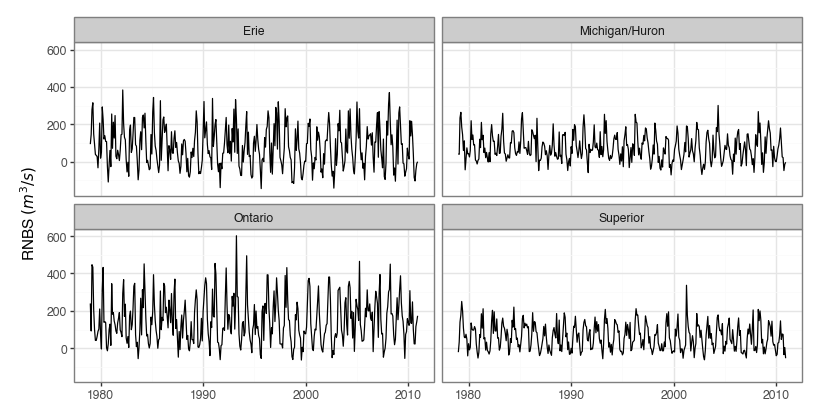

In [72]:
plot_data = (
    lake_data.sel(variable="rnbs")
    .drop_vars(["variable", "type"])
    .to_dataframe(name="rnbs")
    .reset_index()
)

g = (
    ggplot(data=plot_data, mapping=aes(x="Date", y="rnbs"))
    + geom_line()
    + facet_wrap("~lake", labeller=rename_lakes)
    + theme_bw()
    + theme(axis_title_x=element_blank(), figure_size=(8, 4))
    + scale_x_datetime(labels=date_format(fmt="%Y"))
    + ylab("RNBS $\\left(m^3/s\\right)$")
)

g.save("./images/rnbs_raw.pdf")
g

/Users/mmcanear/Projects/NBS-Predictor-MVP/src/data_loading/data_loading.py:370: FutureWarning: In a future version of xarray the default value for join will change from join='outer' to join='exact'. This change will result in the following ValueError: cannot be aligned with join='exact' because index/labels/sizes are not equal along these coordinates (dimensions): 'Date' ('Date',) The recommendation is to set join explicitly for this case.
/Users/mmcanear/Projects/NBS-Predictor-MVP/src/data_loading/data_loading.py:370: FutureWarning: In a future version of xarray the default value for join will change from join='outer' to join='exact'. This change will result in the following ValueError: cannot be aligned with join='exact' because index/labels/sizes are not equal along these coordinates (dimensions): 'Date' ('Date',) The recommendation is to set join explicitly for this case.
/Users/mmcanear/Projects/NBS-Predictor-MVP/src/data_loading/data_loading.py:363: FutureWarning: In a future ve

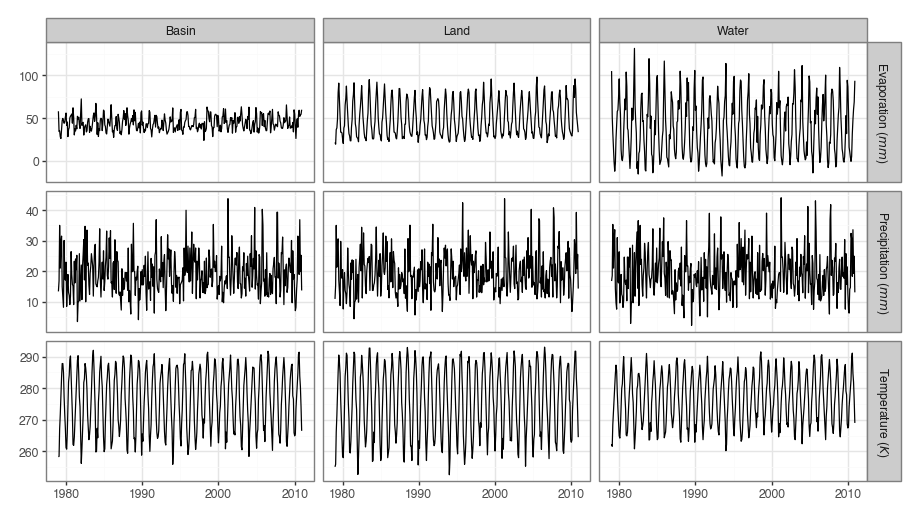

In [73]:
covar_data = (
    load_data(["precip", "temp", "evap"])
    .to_array()
    .sel(type=["Basin", "Land", "Water"], lake="sup")
    .
    # drop_vars("lake").
    dropna("Date")
    .transpose("Date", ...)
)

plot_data = covar_data.to_dataframe(
    dim_order=["Date", "type", "variable"], name="covar"
).reset_index()

g = (
    ggplot(data=plot_data, mapping=aes(x="Date", y="covar"))
    + geom_line()
    + facet_grid(
        "variable~type",
        scales="free_y",
        labeller=lambda x: {
            "evap": "Evaporation ($mm$)",
            "precip": "Precipitation ($mm$)",
            "temp": "Temperature ($K$)",
        }.get(x, x),
    )
    + theme_bw()
    + theme(axis_title=element_blank(), figure_size=(9, 5))
    + scale_x_datetime(labels=date_format(fmt="%Y"))
)

g.save("./images/covars_raw.pdf")
g

In [74]:
preprocessor = XArrayFeatureUnion(
    [
        (
            "preprocess",
            Pipeline(
                steps=[
                    ("scale", XArrayStandardScaler()),
                    ("flatten", FunctionTransformer(flatten_array)),
                ]
            ),
        ),
        ("seasonal", SeasonalFeatures()),
    ]
)

gp_models = {
    "GP_Matern": Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            (
                "model",
                SklearnGPModel(
                    1.0 * kernels.Matern(nu=1.5) * kernels.RationalQuadratic()
                ),
            ),
        ]
    ),
    "MultitaskGP": Pipeline(
        steps=[("preprocess", preprocessor), ("model", MultitaskGP(epochs=100, rank=1))]
    ),
}

simple_models = {
    "SimpleLM": Pipeline(
        steps=[("preprocess", preprocessor), ("model", LinearModel())]
    ),
    "RF": Pipeline(steps=[("preprocess", preprocessor), ("model", RandomForest())]),
    "BoostedTrees": Pipeline(
        steps=[
            ("preprocess", preprocessor),
            ("model", BoostedRegressor(n_estimators=500, learning_rate=0.1)),
        ]
    ),
    "MVT": Pipeline(steps=[("preprocess", preprocessor), ("model", LakeMVT())]),
}

varx_models = {
    "NARX": Pipeline(
        steps=[
            ("preprocess", XArrayStandardScaler()),
            (
                "model",
                NARX(
                    lags={"y": 1, "temp": 0, "precip": 0, "evap": 0},
                    num_warmup=1000,
                    num_chains=4,
                    num_samples=1000,
                ),
            ),
        ]
    ),
    "VARX": Pipeline(
        steps=[
            ("preprocess", XArrayStandardScaler()),
            (
                "model",
                VARX(
                    lags={"y": 1, "precip": 0, "temp": 0, "evap": 0},
                    num_warmup=500,
                    num_chains=4,
                    num_samples=500,
                ),
            ),
        ]
    ),
    "VARX_lag2": Pipeline(
        steps=[
            ("preprocess", XArrayStandardScaler()),
            (
                "model",
                VARX(
                    lags={"y": 2, "precip": 0, "temp": 0, "evap": 0},
                    num_warmup=500,
                    num_chains=4,
                    num_samples=500,
                ),
            ),
        ]
    ),
    "VARX_lag3": Pipeline(
        steps=[
            ("preprocess", XArrayStandardScaler()),
            (
                "model",
                VARX(
                    lags={"y": 3, "precip": 0, "temp": 0, "evap": 0},
                    num_warmup=500,
                    num_chains=4,
                    num_samples=500,
                ),
            ),
        ]
    ),
}

# use only temp and precip
all_models = {
    "Default": Pipeline(
        steps=[("preprocessor", preprocessor), ("model", DefaultEnsemble())]
    ),
    **simple_models,
    **gp_models,
    **varx_models,
}

In [75]:
# run cross validation
results = []
overwrite = False
results_dir = Path("./_scratch/model_results_varx_test")
model_dir = Path("./_scratch/models_varx_test")
results_dir.mkdir(exist_ok=True, parents=True)
model_dir.mkdir(exist_ok=True, parents=True)
for name, model in all_models.items():
    logging.info(f"Fitting {name} model...")
    for i, (train_id, test_id) in enumerate(splits):
        prediction_file = results_dir / f"{name}_{i}.csv"
        if prediction_file.exists() and not overwrite:
            logging.info(f"Loading {name} model (split {i + 1}/{num_splits})")
            predictions = pd.read_csv(prediction_file).assign(split=i + 1)
            predictions["Date"] = pd.to_datetime(predictions["Date"])
        else:
            logging.info(f"Fitting {name} model (split {i + 1}/{num_splits})")
            model.fit(X[train_id], y[train_id])

            try:
                az.to_netcdf(
                    model.named_steps["model"].trace, model_dir / f"{name}_{i}.nc"
                )
            except AttributeError:
                with open(model_dir / f"{name}_{i}.pkl", "wb") as f:
                    pkl.dump(model, f)
            except Exception as e:
                logging.warning(
                    f"Failed to save model {name} (split {i + 1}/{num_splits}): {e}"
                )
                continue

            preds = model.predict(
                X[: max(test_id) + 1],
                y=y[: max(test_id) + 1],
                forecast_steps=forecast_steps,
            )

            array = xr.concat(
                [preds, y[test_id].expand_dims({"value": ["true"]}, axis=-1)],
                dim="value",
            )

            predictions = pd.concat(
                [
                    arr.to_pandas().assign(
                        months_ahead=list(range(1, forecast_steps + 1)), model=name
                    )
                    for arr in array.transpose("lake", ...)
                ],
                axis=0,
                keys=preds.lake.values,
                names=["lake"],
            ).assign(split=i + 1)
            predictions.to_csv(prediction_file)
        results.append(predictions)

cv_results = pd.concat(results, axis=0)
cv_results.head()

INFO:root:Fitting Default model...
INFO:root:Loading Default model (split 1/10)
INFO:root:Loading Default model (split 2/10)
INFO:root:Loading Default model (split 3/10)
INFO:root:Loading Default model (split 4/10)
INFO:root:Loading Default model (split 5/10)
INFO:root:Loading Default model (split 6/10)
INFO:root:Loading Default model (split 7/10)
INFO:root:Loading Default model (split 8/10)
INFO:root:Loading Default model (split 9/10)
INFO:root:Loading Default model (split 10/10)
INFO:root:Fitting SimpleLM model...
INFO:root:Loading SimpleLM model (split 1/10)
INFO:root:Loading SimpleLM model (split 2/10)
INFO:root:Loading SimpleLM model (split 3/10)
INFO:root:Loading SimpleLM model (split 4/10)
INFO:root:Loading SimpleLM model (split 5/10)
INFO:root:Loading SimpleLM model (split 6/10)
INFO:root:Loading SimpleLM model (split 7/10)
INFO:root:Loading SimpleLM model (split 8/10)
INFO:root:Loading SimpleLM model (split 9/10)
INFO:root:Loading SimpleLM model (split 10/10)
INFO:root:Fitting

,lake,Date,mean,lower,upper,std,true,months_ahead,model,split
0,sup,1995-03-01,-0.159,-0.750,0.883,0.455,-0.166,1,Default,1
1,sup,1995-04-01,1.097,0.060,1.812,0.497,0.150,2,Default,1
2,sup,1995-05-01,1.263,0.461,2.485,0.650,1.105,3,Default,1
3,sup,1995-06-01,1.002,0.085,2.229,0.693,0.072,4,Default,1
4,sup,1995-07-01,0.728,-0.167,1.715,0.538,0.924,5,Default,1


In [76]:
cv_results = cv_results[cv_results["months_ahead"] <= 12]
unscaled_predictions = cv_results[
    [
        "Date",
        "lake",
        "model",
        "mean",
        "lower",
        "upper",
        "true",
        "std",
        "months_ahead",
        "split",
    ]
].melt(id_vars=["Date", "model", "lake", "months_ahead", "split"])

unscaled_predictions["lake"] = pd.Categorical(
    unscaled_predictions["lake"],
    categories=["sup", "mic_hur", "eri", "ont"],
    ordered=True,
)

grped_data = (
    unscaled_predictions.pivot_table(
        index=["Date", "model", "variable", "months_ahead", "split"],
        columns=["lake"],
        values="value",
    )
    .reset_index()
    .groupby("variable")
)

scaled_data = []
unscaled_data = []
for var_name, df in grped_data:
    scaled_sub_df = df.copy()
    df[["sup", "mic_hur", "eri", "ont"]] = y_scaler.inverse_transform(
        df[["sup", "mic_hur", "eri", "ont"]]
    )
    df = df.melt(
        id_vars=["Date", "model", "months_ahead", "split"],
        value_vars=["sup", "mic_hur", "eri", "ont"],
        var_name="lake",
        value_name=var_name,
    ).set_index(["Date", "model", "lake", "months_ahead", "split"])
    unscaled_data.append(df)
    scaled_sub_df = scaled_sub_df.melt(
        id_vars=["Date", "model", "months_ahead", "split"],
        value_vars=["sup", "mic_hur", "eri", "ont"],
        var_name="lake",
        value_name=var_name,
    ).set_index(["Date", "model", "lake", "months_ahead", "split"])
    scaled_data.append(scaled_sub_df)

scaled_data = reduce(
    partial(pd.merge, left_index=True, right_index=True), scaled_data
).reset_index()
unscaled_data = reduce(
    partial(pd.merge, left_index=True, right_index=True), unscaled_data
).reset_index()

scaled_data


<positron-console-cell-76>:24: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior


,Date,model,lake,months_ahead,split,lower,mean,std,true,upper
0,1995-03-01,BoostedTrees,sup,1,1,-0.578,-0.249,0.582,-0.166,1.752
1,1995-03-01,Default,sup,1,1,-0.750,-0.159,0.455,-0.166,0.883
2,1995-03-01,GP_Matern,sup,1,1,-0.819,-0.091,0.371,-0.166,0.636
3,1995-03-01,MVT,sup,1,1,-1.195,-0.205,0.639,-0.166,0.830
4,1995-03-01,MultitaskGP,sup,1,1,-0.708,-0.063,0.322,-0.166,0.581
...,...,...,...,...,...,...,...,...,...,...
5275,2005-11-01,RF,ont,12,10,-0.935,0.165,0.604,0.537,1.283
5276,2005-11-01,SimpleLM,ont,12,10,-0.376,0.509,0.450,0.537,1.393
5277,2005-11-01,VARX,ont,12,10,-0.300,0.409,0.440,0.537,1.088
5278,2005-11-01,VARX_lag2,ont,12,10,-0.194,0.463,0.459,0.537,1.272


In [77]:
scaled_data.groupby(["lake", "model"]).apply(
    summarize, include_groups=False
).reset_index()

,lake,model,rmse,mae,mape,variance,bias,coverage,interval_len,crps,N,r2
0,eri,BoostedTrees,0.508,0.403,2.627,0.253,0.067,0.858,2.022,0.281,120.000,0.650
1,eri,Default,0.688,0.556,2.069,0.468,0.072,0.875,2.229,0.387,120.000,0.100
2,eri,GP_Matern,0.465,0.361,5.125,0.209,0.084,0.917,1.573,0.257,120.000,0.751
3,eri,MVT,0.683,0.550,5.049,0.467,0.016,0.917,2.363,0.385,120.000,0.068
4,eri,MultitaskGP,0.467,0.371,32.420,0.210,0.091,0.925,1.745,0.261,120.000,0.747
5,eri,NARX,0.523,0.401,4.966,0.272,0.035,0.892,1.570,0.287,120.000,0.708
6,eri,RF,0.500,0.399,1.740,0.244,0.077,0.942,2.078,0.286,120.000,0.596
7,eri,SimpleLM,0.483,0.371,1.850,0.227,0.079,0.900,1.731,0.268,120.000,0.731
8,eri,VARX,0.491,0.393,1.437,0.239,0.046,0.892,1.510,0.277,120.000,0.732
9,eri,VARX_lag2,0.490,0.388,1.289,0.237,0.055,0.892,1.528,0.275,120.000,0.733


In [78]:
scaled_data.groupby(["model"]).apply(summarize, include_groups=False).round(3)

,rmse,mae,mape,variance,bias,coverage,interval_len,crps,N,r2
model,,,,,,,,,,
BoostedTrees,0.483,0.381,1.966,0.229,0.070,0.817,1.978,0.271,480.000,0.675
Default,0.674,0.539,5.714,0.450,0.067,0.867,2.104,0.379,480.000,0.220
GP_Matern,0.429,0.332,2.187,0.173,0.104,0.933,1.573,0.236,480.000,0.785
MVT,0.674,0.534,3.455,0.453,0.025,0.898,2.194,0.377,480.000,0.209
MultitaskGP,0.436,0.340,8.948,0.179,0.106,0.935,1.608,0.240,480.000,0.772
NARX,0.455,0.345,3.394,0.202,0.075,0.881,1.384,0.249,480.000,0.769
RF,0.529,0.414,5.024,0.273,0.087,0.923,2.049,0.295,480.000,0.539
SimpleLM,0.450,0.347,3.331,0.194,0.091,0.915,1.578,0.249,480.000,0.765
VARX,0.435,0.338,1.916,0.184,0.072,0.873,1.315,0.241,480.000,0.785


In [ ]:
# get the CRPS column
def rollup_agg(df, groupings, fn=summarize):
    full_groupings = (
        df.groupby(groupings, observed=False)
        .apply(fn, include_groups=False)
        .reset_index()
    )
    all_groupings = (
        df.groupby(groupings[:-1], observed=False)
        .apply(fn, include_groups=False)
        .reset_index()
    )
    all_groupings[groupings[-1]] = "All"

    return pd.concat(
        [full_groupings, all_groupings.assign(lake="All")], axis=0, ignore_index=True
    ).set_index(groupings)


CRPS_table = rollup_agg(scaled_data, ["model", "lake"])["crps"].reset_index()
rename_lakes_vec = np.vectorize(rename_lakes)
CRPS_table["lake"] = pd.Categorical(
    rename_lakes_vec(CRPS_table["lake"]),
    categories=["Superior", "Michigan/Huron", "Erie", "Ontario", "All"],
)
print(
    CRPS_table.pivot_table(columns=["lake"], index=["model"], values="crps").to_latex(
        float_format="%.3f"
    )
)

\begin{tabular}{lrrrrr}
\toprule
lake & Superior & Michigan/Huron & Erie & Ontario & All \\
model &  &  &  &  &  \\
\midrule
BoostedTrees & 0.266 & 0.261 & 0.281 & 0.276 & 0.271 \\
Default & 0.341 & 0.395 & 0.387 & 0.394 & 0.379 \\
GP_Matern & 0.231 & 0.203 & 0.257 & 0.252 & 0.236 \\
MVT & 0.339 & 0.388 & 0.385 & 0.397 & 0.377 \\
MultitaskGP & 0.243 & 0.211 & 0.261 & 0.247 & 0.240 \\
NARX & 0.240 & 0.226 & 0.287 & 0.245 & 0.249 \\
RF & 0.295 & 0.300 & 0.286 & 0.300 & 0.295 \\
SimpleLM & 0.241 & 0.206 & 0.268 & 0.282 & 0.249 \\
VARX & 0.225 & 0.206 & 0.277 & 0.256 & 0.241 \\
VARX_lag2 & 0.224 & 0.210 & 0.275 & 0.254 & 0.241 \\
VARX_lag3 & 0.227 & 0.211 & 0.276 & 0.256 & 0.242 \\
\bottomrule
\end{tabular}



<positron-console-cell-79>:20: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior


In [80]:
# NOTE: this is not a BAD idea necessarily, but with only 5 splits this doesn't
# have enough sample size to be useful
scaled_data[scaled_data["months_ahead"].isin([1, 3, 6, 12])].groupby(
    ["months_ahead", "model"]
).apply(summarize, include_groups=False).reset_index()

,months_ahead,model,rmse,mae,mape,variance,bias,coverage,interval_len,crps,N,r2
0,1,BoostedTrees,0.599,0.458,1.123,0.333,0.160,0.775,2.164,0.338,40.000,0.609
1,1,Default,0.647,0.501,2.917,0.418,-0.022,0.900,2.129,0.360,40.000,0.371
2,1,GP_Matern,0.572,0.434,0.714,0.310,0.132,0.850,1.585,0.317,40.000,0.729
3,1,MVT,0.651,0.496,1.798,0.420,-0.059,0.900,2.188,0.363,40.000,0.364
4,1,MultitaskGP,0.566,0.439,0.684,0.301,0.141,0.825,1.629,0.317,40.000,0.721
5,1,NARX,0.583,0.420,0.786,0.340,0.018,0.825,1.321,0.308,40.000,0.727
6,1,RF,0.604,0.494,1.892,0.346,0.135,0.850,2.028,0.355,40.000,0.554
7,1,SimpleLM,0.610,0.507,2.902,0.366,0.079,0.775,1.579,0.360,40.000,0.676
8,1,VARX,0.569,0.450,1.120,0.324,0.006,0.725,1.280,0.326,40.000,0.706
9,1,VARX_lag2,0.568,0.457,0.969,0.323,0.011,0.725,1.296,0.327,40.000,0.711


/Users/mmcanear/Projects/NBS-Predictor-MVP/.venv/lib/python3.12/site-packages/plotnine/ggplot.py:623: PlotnineWarning: Saving 12 x 6 in image.
/Users/mmcanear/Projects/NBS-Predictor-MVP/.venv/lib/python3.12/site-packages/plotnine/ggplot.py:624: PlotnineWarning: Filename: ./images/model_comparison.pdf


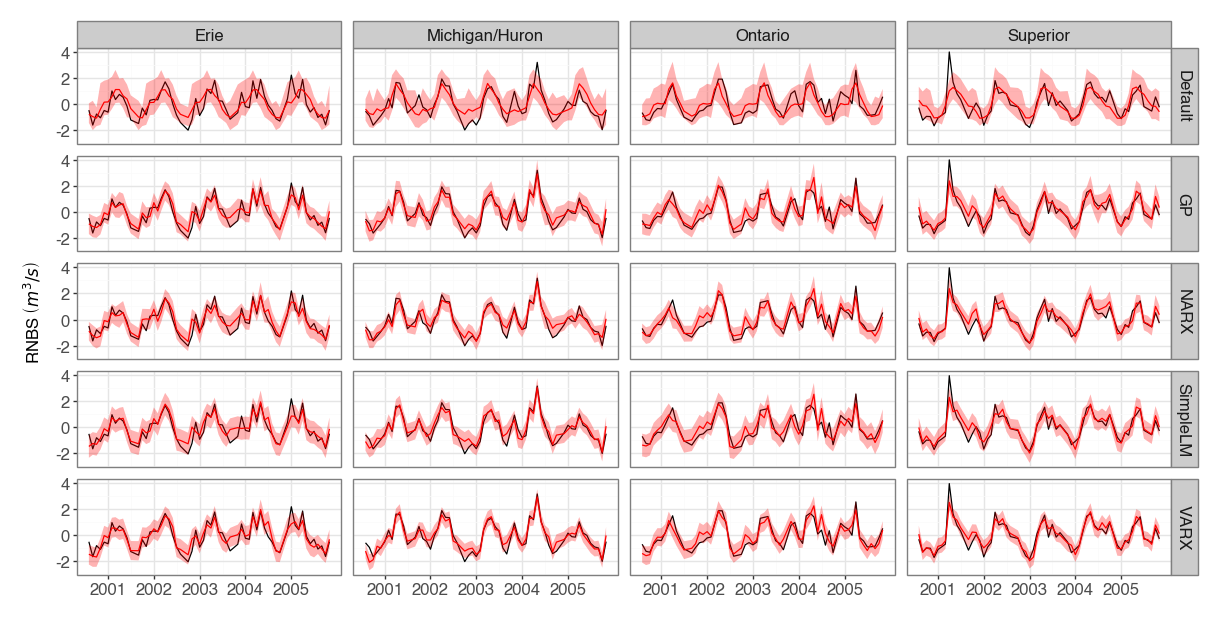

In [ ]:
def facet_rename(x):
    # labels = {"eri": "Erie", "sup": "Superior", "mic_hur": "Michigan/Huron", "ont": "Ontario", "GP_Matern": "GP"}
    labels = {
        "sup": "Superior",
        "mic_hur": "Michigan/Huron",
        "eri": "Erie",
        "ont": "Ontario",
        "GP_Matern": "GP",
    }
    return labels.get(x, x)


unscaled_plot_data = scaled_data[
    (scaled_data["model"].isin(["Default", "GP_Matern", "VARX", "SimpleLM", "NARX"]))
    & (scaled_data["split"] >= 6)
]

g = (
    ggplot(data=unscaled_plot_data, mapping=aes(x="Date", y="mean"))
    + geom_line(mapping=aes(x="Date", y="true"), color="black", inherit_aes=False)
    + geom_line(color="red")
    + facet_grid("model~lake", labeller=facet_rename)
    + geom_ribbon(
        mapping=aes(x="Date", ymin="lower", ymax="upper"), alpha=0.3, fill="red"
    )
    + ylab("RNBS $\\left(m^3/s\\right)$")
    + theme_bw()
    + theme(
        text=element_text(size=12), figure_size=(12, 6), axis_title_x=element_blank()
    )
    + scale_x_datetime(
        limits=[
            pd.Timestamp(unscaled_plot_data.Date.min()),
            pd.Timestamp(unscaled_plot_data.Date.max()),
        ],
        labels=date_format(fmt="%Y"),
        breaks=pd.date_range(
            start=unscaled_plot_data.Date.min(),
            end=unscaled_plot_data.Date.max(),
            freq="YS",
        ),
    )
)

g.save("./images/model_comparison.pdf")
g

# Claims and Comparisons

## (1) Autoregressive terms are not very helpful


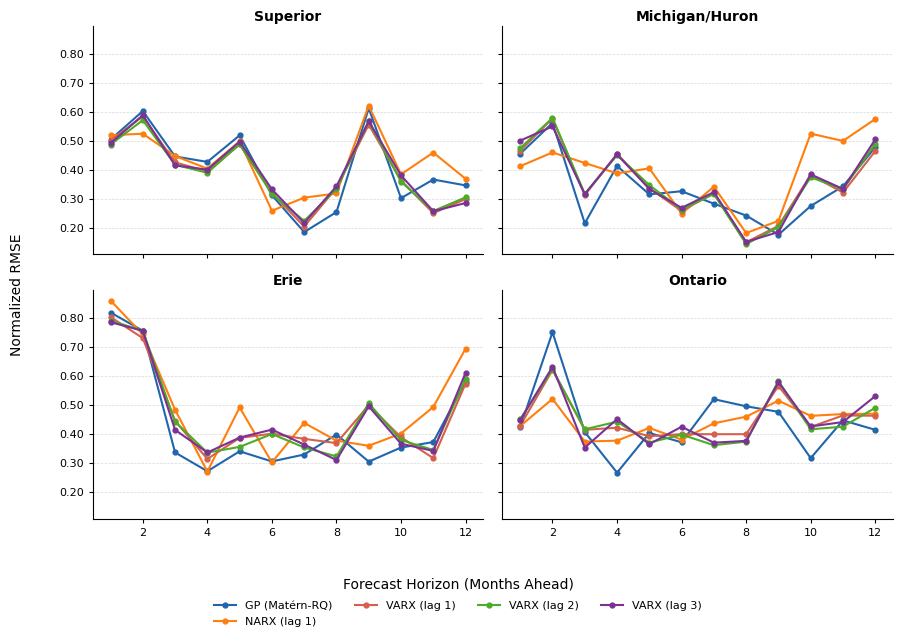

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# Academic color palette - colorblind-friendly, print-safe
MODEL_COLORS = {
    "GP_Matern": "#2166ac",
    "VARX": "#d6604d",
    "VARX_lag2": "#4dac26",
    "VARX_lag3": "#7b3294",
    "NARX": "#ff7f0e",
}
MODEL_LABELS = {
    "GP_Matern": "GP (Matérn-RQ)",
    "VARX": "VARX (lag 1)",
    "VARX_lag2": "VARX (lag 2)",
    "VARX_lag3": "VARX (lag 3)",
    "NARX": "NARX (lag 1)",
}

scaled_ar_data = scaled_data[
    scaled_data["model"].isin(["GP_Matern", "VARX", "VARX_lag2", "VARX_lag3", "NARX"])
]
ar_plot_data = (
    scaled_ar_data.groupby(["months_ahead", "model", "lake"])
    .apply(summarize, include_groups=False)
    .reset_index()
)
lake_list = scaled_ar_data["lake"].unique().tolist()

fig, axs = plt.subplots(nrows=2, ncols=2, figsize=(9, 6), sharey=True, sharex=True)
axs = axs.flatten()

for i, lake in enumerate(lake_list):
    ax = axs[i]
    lake_data = ar_plot_data[ar_plot_data["lake"] == lake]

    for model, group in lake_data.groupby("model"):
        ax.plot(
            group["months_ahead"],
            group["rmse"],
            label=MODEL_LABELS.get(model, model),
            color=MODEL_COLORS.get(model, None),
            marker="o",
            markersize=3.5,
            linewidth=1.5,
        )

    ax.set_title(facet_rename(lake), fontsize=10, fontweight="bold", pad=4)

    # Clean up spines
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_linewidth(0.8)
    ax.spines["bottom"].set_linewidth(0.8)

    ax.tick_params(axis="both", labelsize=8, length=3)
    ax.xaxis.set_major_locator(ticker.MultipleLocator(2))
    ax.yaxis.set_major_formatter(ticker.FormatStrFormatter("%.2f"))
    ax.grid(axis="y", linestyle="--", linewidth=0.5, alpha=0.5)

for j in range(i + 1, 4):
    fig.delaxes(axs[j])

fig.text(0.5, 0.01, "Forecast Horizon (Months Ahead)", ha="center", fontsize=10)
fig.text(
    0.01,
    0.5,
    "Normalized RMSE",
    ha="center",
    va="center",
    rotation="vertical",
    fontsize=10,
)

handles, labels = axs[0].get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    loc="lower center",
    ncol=4,
    bbox_to_anchor=(0.5, -0.07),
    fontsize=8,
    frameon=False,  # no box around legend
)

plt.tight_layout(rect=[0.04, 0.07, 1, 1])
plt.savefig("ar_rmse_by_lake.pdf", bbox_inches="tight", dpi=300)
plt.show()

## (2) Findings from performance table



In [83]:
scaled_data.groupby(["model"]).apply(summarize, include_groups=False).round(3)

,rmse,mae,mape,variance,bias,coverage,interval_len,crps,N,r2
model,,,,,,,,,,
BoostedTrees,0.483,0.381,1.966,0.229,0.070,0.817,1.978,0.271,480.000,0.675
Default,0.674,0.539,5.714,0.450,0.067,0.867,2.104,0.379,480.000,0.220
GP_Matern,0.429,0.332,2.187,0.173,0.104,0.933,1.573,0.236,480.000,0.785
MVT,0.674,0.534,3.455,0.453,0.025,0.898,2.194,0.377,480.000,0.209
MultitaskGP,0.436,0.340,8.948,0.179,0.106,0.935,1.608,0.240,480.000,0.772
NARX,0.455,0.345,3.394,0.202,0.075,0.881,1.384,0.249,480.000,0.769
RF,0.529,0.414,5.024,0.273,0.087,0.923,2.049,0.295,480.000,0.539
SimpleLM,0.450,0.347,3.331,0.194,0.091,0.915,1.578,0.249,480.000,0.765
VARX,0.435,0.338,1.916,0.184,0.072,0.873,1.315,0.241,480.000,0.785


<ol type="a">
<li>Gaussian processes perform best overall in terms of RMSE, coverage, and error estimation for forecasting.</li>
<li>VARX and NARX models improve over a SimpleLM model, but not by a whole lot.</li>
<li>Tree based methods like random forests and boosted random forests (XGBoost) don't do as well in this scenario and don't give great confidence intervals.</li>
<li>Additional autoregressive terms do not improve the overall forecast accuracy.</li>
</ol>


## (3) Individual Lakes Performance

In [84]:
scaled_data.groupby(["lake", "model"]).apply(summarize, include_groups=False).round(
    3
).reset_index()

,lake,model,rmse,mae,mape,variance,bias,coverage,interval_len,crps,N,r2
0,eri,BoostedTrees,0.508,0.403,2.627,0.253,0.067,0.858,2.022,0.281,120.000,0.650
1,eri,Default,0.688,0.556,2.069,0.468,0.072,0.875,2.229,0.387,120.000,0.100
2,eri,GP_Matern,0.465,0.361,5.125,0.209,0.084,0.917,1.573,0.257,120.000,0.751
3,eri,MVT,0.683,0.550,5.049,0.467,0.016,0.917,2.363,0.385,120.000,0.068
4,eri,MultitaskGP,0.467,0.371,32.420,0.210,0.091,0.925,1.745,0.261,120.000,0.747
5,eri,NARX,0.523,0.401,4.966,0.272,0.035,0.892,1.570,0.287,120.000,0.708
6,eri,RF,0.500,0.399,1.740,0.244,0.077,0.942,2.078,0.286,120.000,0.596
7,eri,SimpleLM,0.483,0.371,1.850,0.227,0.079,0.900,1.731,0.268,120.000,0.731
8,eri,VARX,0.491,0.393,1.437,0.239,0.046,0.892,1.510,0.277,120.000,0.732
9,eri,VARX_lag2,0.490,0.388,1.289,0.237,0.055,0.892,1.528,0.275,120.000,0.733


In [ ]:
scaled_data

,Date,model,lake,months_ahead,split,lower,mean,std,true,upper
0,1995-03-01,BoostedTrees,sup,1,1,-0.578,-0.249,0.582,-0.166,1.752
1,1995-03-01,Default,sup,1,1,-0.750,-0.159,0.455,-0.166,0.883
2,1995-03-01,GP_Matern,sup,1,1,-0.819,-0.091,0.371,-0.166,0.636
3,1995-03-01,MVT,sup,1,1,-1.195,-0.205,0.639,-0.166,0.830
4,1995-03-01,MultitaskGP,sup,1,1,-0.708,-0.063,0.322,-0.166,0.581
...,...,...,...,...,...,...,...,...,...,...
5275,2005-11-01,RF,ont,12,10,-0.935,0.165,0.604,0.537,1.283
5276,2005-11-01,SimpleLM,ont,12,10,-0.376,0.509,0.450,0.537,1.393
5277,2005-11-01,VARX,ont,12,10,-0.300,0.409,0.440,0.537,1.088
5278,2005-11-01,VARX_lag2,ont,12,10,-0.194,0.463,0.459,0.537,1.272


1) Models predict much higher variability for Erie and Ontario.
2) Cross lake correlations are significantly nonzero in the residuals, even after accounting for covariates and random intercepts by month.
   

In [86]:
trace = az.from_netcdf(model_dir / "VARX_9.nc")

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Define valid lower-triangle (series, lake) pairs
valid_set = [
    ("sup", "sup"),
    ("mic_hur", "sup"),
    ("mic_hur", "mic_hur"),
    ("eri", "sup"),
    ("eri", "mic_hur"),
    ("eri", "eri"),
    ("ont", "sup"),
    ("ont", "mic_hur"),
    ("ont", "eri"),
    ("ont", "ont"),
]

# Grid order
lake_order = ["sup", "mic_hur", "eri", "ont"]
series_order = ["sup", "mic_hur", "eri", "ont"]

fig, axs = plt.subplots(nrows=4, ncols=4, figsize=(6, 6))
axs = axs.flatten()

# Valid subplot positions in lower triangle
triangle_plots = [0, 4, 5, 8, 9, 10, 12, 13, 14, 15]
valid_pairs = valid_set.copy()

for i in range(16):
    ax = axs[i]
    ax.set_prop_cycle(None)

    if i not in triangle_plots:
        ax.set_visible(False)
        continue

    # Get series/lake pair
    series, lake = valid_pairs.pop(0)
    subtrace = trace.posterior["corr"].sel(series=series, lakes=lake)

    # Plot KDE for each chain
    for c in range(subtrace.chain.size):
        sns.kdeplot(
            subtrace.sel(chain=subtrace.chain.values[c]).values.flatten(),
            ax=ax,
            fill=False,
            alpha=0.5,
            linewidth=1,
        )

    ax.set_xlim(-1.25, 1.25)
    ax.set_yticks([])
    ax.set_ylabel("")
    ax.set_xlabel("")

    # Determine position
    row = i // 4
    col = i % 4

    # Only bottom row gets x-axis ticks
    if row == 3:
        ax.set_xticks([-1.0, -0.5, 0.0, 0.5, 1.0])
        ax.set_xticklabels(["–1.0", "–0.5", "0", "0.5", "1.0"], ha="center", fontsize=8)

    else:
        ax.set_xticks([])
        ax.tick_params(axis="x", labelsize=0)

    # Top row gets lake label
    if row == col:
        ax.set_title(rename_lakes(lake), fontsize=10, pad=6)

    # Leftmost column gets series label
    if col == 0:
        ax.annotate(
            rename_lakes(series),
            xy=(0, 0.5),
            xycoords="axes fraction",
            ha="right",
            va="center",
            fontsize=10,
            xytext=(-6, 0),
            textcoords="offset points",
        )

# Tight layout with minimal spacing
# plt.subplots_adjust(wspace=0.0, hspace=0.0, left=0.08, right=0.95, top=0.9, bottom=0.08)
plt.subplots_adjust(
    wspace=0.0, hspace=0.0, left=0.20, right=0.95, top=0.95, bottom=0.08
)

plt.savefig("./images/correlation_matrices.pdf")


<positron-console-cell-87>:43: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
<positron-console-cell-87>:43: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
<positron-console-cell-87>:43: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
<positron-console-cell-87>:43: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
INFO:matplotlib.font_manager:Fontsize 0.00 < 1.0 pt not allowed by FreeType. Setting fontsize = 1 pt
INFO:matplotlib.font_manager:Fontsize 0.00 < 1.0 pt not allowed by FreeType. Setting fontsize = 1 pt
INFO:matplotlib.font_manager:Fontsize 0.00 < 1.0 pt not allowed by FreeType. Setting fontsize = 1 pt
INFO:matplotlib.font_manager:Fontsize 0.00 < 1.0 pt not allowed by FreeType. Setting fontsize = 1 pt
INFO:mat

/Users/mmcanear/Projects/NBS-Predictor-MVP/.venv/lib/python3.12/site-packages/arviz/stats/density_utils.py:488: UserWarning: Your data appears to have a single value or no finite values


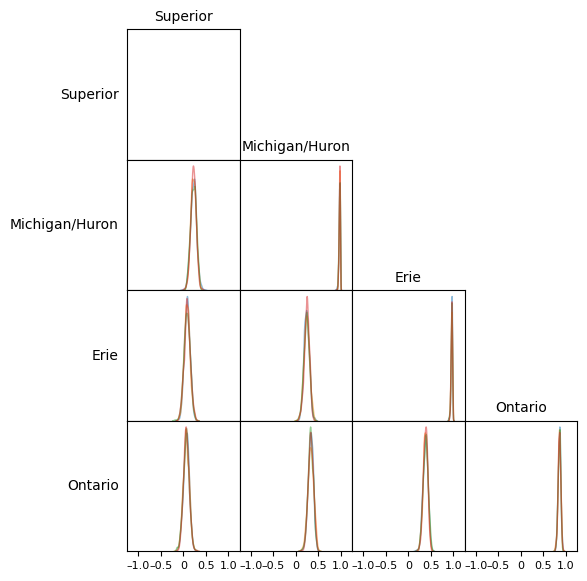

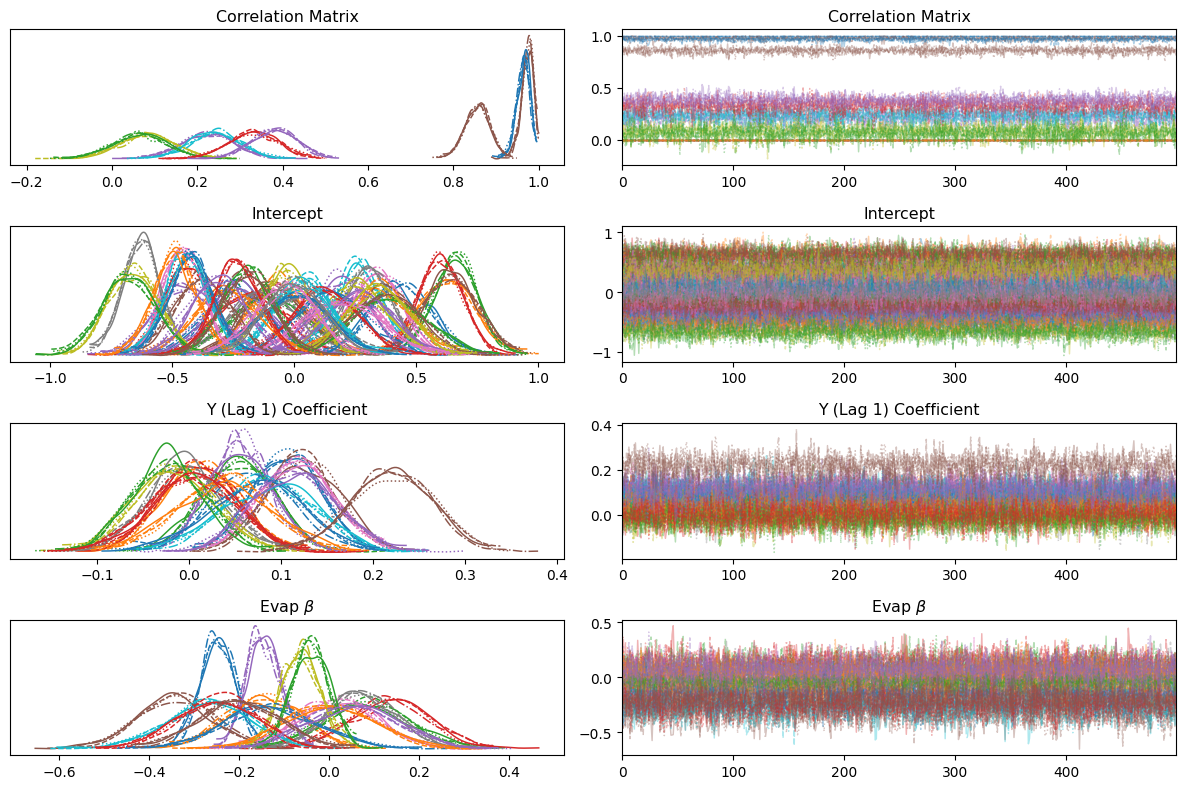

In [ ]:
az.plot_trace(
    trace.rename(
        {
            "corr": "Correlation Matrix",
            "intercept": "Intercept",
            "y_alpha": r"Y (Lag 1) Coefficient",
            "evap_alpha": r"Evap $\beta$",
        }
    ),
    var_names=[
        "Correlation Matrix",
        "Intercept",
        "Y (Lag 1) Coefficient",
        r"Evap $\beta$",
    ],
    compact=True,
)
plt.tight_layout()
plt.show()

plt.savefig("./images/trace_plots.pdf", bbox_inches="tight", dpi=300)

Data variables:
    corr                  (chain, draw, series, lakes) float32 128kB 1.0 ... ...
    covar_sigma           (chain, draw) float32 8kB 0.1876 0.2035 ... 0.1919
    evap_alpha            (chain, draw, series, lakes) float32 128kB -0.2652 ...
    global_mu             (chain, draw) float32 8kB -0.01558 ... -0.07191
    intercept             (chain, draw, month, lakes) float32 384kB -0.3342 ....
    intercept_decentered  (chain, draw, intercept_decentered_dim_0, intercept_decentered_dim_1) float32 384kB ...
    intercept_sigma       (chain, draw) float32 8kB 0.406 0.3823 ... 0.3087
    nu                    (chain, draw) float32 8kB 8.157 8.824 ... 12.77 8.709
    precip_alpha          (chain, draw, series, lakes) float32 128kB 0.4248 ....
    temp_alpha            (chain, draw, series, lakes) float32 128kB -0.02619...
    theta                 (chain, draw, lakes) float32 32kB 0.09443 ... 0.115
    y_alpha               (chain, draw, series, lakes, lag) float32 128kB 0.0...